# BVD Circuit Time-Series Analysis — All Samples

Fits a 1st-order BVD equivalent circuit to the dominant resonant peak (~200 kHz) of the real-part impedance for sample_0, sample_5, and sample_10 across all measurement sessions.
 Shared model and fitting utilities live in bvd_utils.py.
How to use:
1. Edit the USER SETTINGS block in the Configuration section
2. Run all cells top-to-bottom
3. Results are saved to BVD_Fits/<SAVE_FILENAME>
4. Use the saved BVD fits to train a CNN in the ML_ALT_CNN.ipynb

 Tip: all user-facing settings are in the Configuration section — nothing else needs editing.


# 1. Import Libraries & Load Helper Module
Imports standard scientific libraries and reloads bvd_utils.py so any edits to the

helper module are picked up immediately without restarting the kernel.

In [1]:
# ============================================================
# Author : Mads Kofod Dahl
# License: MIT License (2026)
# ============================================================

import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os, re, warnings
from datetime import datetime
warnings.filterwarnings('ignore')
import bvd_utils as bvd


# 2. Configuration
All user-facing settings are here. Edit this section, then run it before anything else.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# USER SETTINGS — edit these; no other section needs to change
# ═══════════════════════════════════════════════════════════════════════════════

# ── Output ────────────────────────────────────────────────────────────────────
SAVE_FILENAME        = "fitted_bvd_params.csv"  # saved to BVD_Fits/
PLOT_INDIVIDUAL_FITS = False   # True → render one diagnostic figure per fit

# ── Dataset path ──────────────────────────────────────────────────────────────
CORROSION_DATASET_PATH = os.path.join(os.getcwd(), "Corrosion_Dataset")

# ── Date window (set to None to load all sessions) ────────────────────────────
START_DATE = "2026-02-12"
END_DATE   = "2026-03-30"   # inclusive

# ── Samples to process ────────────────────────────────────────────────────────
SAMPLES = ['sample_0', 'sample_5', 'sample_10']

# ── Per-sample resonant peak frequency range (Hz) ─────────────────────────────
FREQ_RANGES = {
    'sample_0':  (180_000, 205_000),
    'sample_5':  (180_000, 205_000),
    'sample_10': (210_000, 250_000),
}

# ═══════════════════════════════════════════════════════════════════════════════
# ADVANCED SETTINGS — change only if fits are poor
# ═══════════════════════════════════════════════════════════════════════════════


# Per-sample initial seeds (R0, C0, R1, L1, C1)
INITIAL_SEEDS = {
    'sample_0':  {'R0': 222,  'C0': 1.92e-9,   'R1': 382.727,  'L1': 0.02, 'C1': 3.365e-11},
    'sample_5':  {'R0': 775,  'C0': 3.0362e-09, 'R1': 663.7215, 'L1': 0.02, 'C1': 3.44e-11},
    'sample_10': {'R0': 140,  'C0': 7.96e-10,   'R1': 1955,     'L1': 0.02, 'C1': 2.45e-11},
}

# Per-sample display metadata (colour, marker, legend label)
SAMPLE_META = {
    'sample_0':  {'color': '#1f77b4', 'marker': 'o', 'label': 'Sample 1'},
    'sample_5':  {'color': '#ff7f0e', 'marker': 's', 'label': 'Sample 2'},
    'sample_10': {'color': '#2ca02c', 'marker': '^', 'label': 'Sample 3'},
}

# ═══════════════════════════════════════════════════════════════════════════════

def seed_to_bounds(seed, margin=0.10):
    """Build ±margin bounds around a seed dict (R0, C0, R1, L1, C1)."""
    keys = ['R0', 'C0', 'R1', 'L1', 'C1']
    return [(seed[k]*(1-margin), seed[k]*(1+margin)) for k in keys]

print("Configuration set. Samples:", SAMPLES)
print(f"Date window: {START_DATE} → {END_DATE}")
for s, (f0, f1) in FREQ_RANGES.items():
    print(f"  {s}: {f0/1000:.1f} – {f1/1000:.1f} kHz")
print(f"Output: BVD_Fits/{SAVE_FILENAME}")
print(f"Individual fit plots: {PLOT_INDIVIDUAL_FITS}")

Configuration set. Samples: ['sample_0', 'sample_5', 'sample_10']
Date window: 2026-02-12 → 2026-03-30
  sample_0: 180.0 – 205.0 kHz
  sample_5: 180.0 – 205.0 kHz
  sample_10: 210.0 – 250.0 kHz
Output: BVD_Fits/fitted_bvd_params.csv
Individual fit plots: False



# 3. Load All Corrosion Data
Scans Corrosion_Dataset/ for session folders matching the date window, loads each sample CSV, applies the known scaling corrections, and returns a single combined DataFrame.


In [3]:
data_frames = []
for sample_name in SAMPLES:
    start_freq, end_freq = FREQ_RANGES[sample_name]
    df = bvd.load_all_corrosion_data(
        CORROSION_DATASET_PATH,
        start_freq,
        end_freq,
        [sample_name],
        start_date=START_DATE,
        end_date=END_DATE,
    )
    data_frames.append(df)

data = pd.concat(data_frames, ignore_index=True)

print(f"\nTotal rows        : {len(data):,}")
print(f"Unique timestamps : {data['timestamp'].nunique()}")
print(f"Samples present   : {data['sample'].unique().tolist()}")
print("\nRows per sample:")
print(data.groupby('sample').size().to_string())

Found 24 measurement folders.
Found 24 measurement folders.
Found 24 measurement folders.

Total rows        : 20,600
Unique timestamps : 24
Samples present   : ['sample_0', 'sample_5', 'sample_10']

Rows per sample:
sample
sample_0     5750
sample_10    9600
sample_5     5250


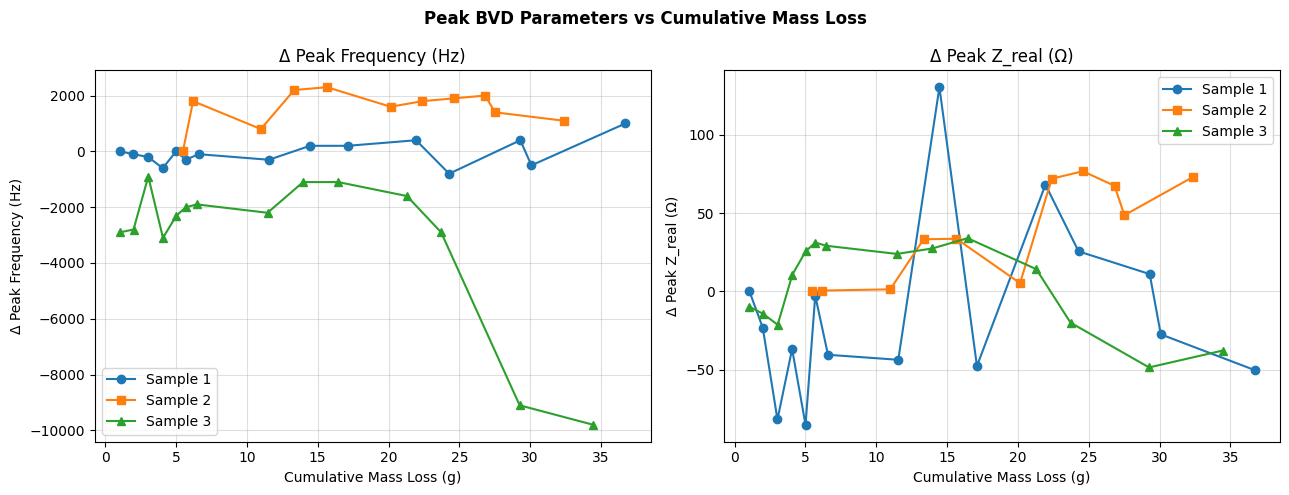

In [4]:
# ── Extract peak frequency and peak Z_real per (timestamp, sample) ────────────
peak_rows = []
for (ts, sname), grp in data.groupby(['timestamp', 'sample']):
    idx_peak = grp['Z_real'].idxmax()
    peak_rows.append({
        'timestamp': ts,
        'sample':    sname,
        'f_peak_hz': grp.loc[idx_peak, 'Frequency (Hz)'],
        'z_peak':    grp.loc[idx_peak, 'Z_real'],
    })

peak_df = pd.DataFrame(peak_rows).sort_values(['sample', 'timestamp'])

# ── Remove outliers on RAW values before any delta/baseline calculation ────────
def iqr_mask(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series >= q1 - k * iqr) & (series <= q3 + k * iqr)

for col in ['f_peak_hz', 'z_peak']:
    mask = peak_df.groupby('sample')[col].transform(iqr_mask)
    peak_df = peak_df[mask]

# ── Now compute baseline and deltas on the cleaned data ───────────────────────
peak_df['f_peak_0'] = peak_df.groupby('sample')['f_peak_hz'].transform('first')
peak_df['z_peak_0'] = peak_df.groupby('sample')['z_peak'].transform('first')
peak_df['delta_f_hz'] = peak_df['f_peak_hz'] - peak_df['f_peak_0']
peak_df['delta_z']    = peak_df['z_peak']    - peak_df['z_peak_0']
peak_df['_date']      = peak_df['timestamp'].dt.normalize()

# ── Load mass loss ─────────────────────────────────────────────────────────────
mass_loss_path = os.path.join(CORROSION_DATASET_PATH, 'mass_loss.csv')
ml_raw = pd.read_csv(mass_loss_path, parse_dates=['Date'])

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_cols = [
    ('delta_f_hz', 'Δ Peak Frequency (Hz)'),
    ('delta_z',    'Δ Peak Z_real (Ω)'),
]

for ax, (col, ylabel) in zip(axes, plot_cols):
    for sample_name in SAMPLES:
        meta = SAMPLE_META[sample_name]
        sdf  = peak_df[peak_df['sample'] == sample_name]
        ml_s = ml_raw[ml_raw['Sample'] == sample_name][['Date', 'Cumulative_Mass_Loss_g']]
        daily  = sdf[['_date', col]].groupby('_date', as_index=False)[col].mean()
        merged = daily.merge(ml_s, left_on='_date', right_on='Date', how='inner')
        if merged.empty:
            continue
        ax.plot(merged['Cumulative_Mass_Loss_g'], merged[col],
                color=meta['color'], marker=meta['marker'],
                linewidth=1.5, markersize=6, label=meta['label'])

    ax.set_xlabel('Cumulative Mass Loss (g)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(True, alpha=0.4)
    ax.legend()

fig.suptitle('Peak BVD Parameters vs Cumulative Mass Loss', fontweight='bold')
plt.tight_layout()
plt.show()


# 4. Fit BVD Circuit per Sample per Timestamp

Uses a warm-start strategy: after the first successful fit the resulting parameters become
the seed (and bounds basis) for the next timestamp, letting the optimizer track slow drift
efficiently without getting stuck in bad local minima.

Fits below R2_ACCEPT trigger automatic retries with progressively wider bounds. If a fit
remains poor after all retries the warm-start is reset so the next session starts fresh.

In [ ]:
all_results = []
timestamps_sorted = sorted(data['timestamp'].unique())

# ── Thresholds ────────────────────────────────────────────────────────────────
R2_ACCEPT      = 0.75  # minimum acceptable r2_real; fits below this trigger retries
MAX_RETRIES    = 20    # maximum retry attempts with full DEFAULT_BOUNDS
WARM_MARGIN    = 0.10  # bounds width around previous good fit (±30 %)
INITIAL_MARGIN = 0.30  # bounds width around INITIAL_SEEDS (±70 %)
PEAK_WEIGHT = 1.0      # Attempts to fit the resonant peak more accurately by weighting the peak region more heavily in the loss function.
L1_BASELINE = 0.020    # L1 represents the mass of samples. Initial weight is the same for all samples

print(f"Fitting BVD for {len(timestamps_sorted)} timestamps × {len(SAMPLES)} samples "
      f"= {len(timestamps_sorted)*len(SAMPLES)} fits total\n")

# last_params[sample_name] holds the most recent GOOD fit used as warm-start seed
last_params = {}

for ts in timestamps_sorted:
    ts_str = ts.strftime('%Y-%m-%d %H:%M')
    for sample_name in SAMPLES:
        subset = data[(data['timestamp'] == ts) & (data['sample'] == sample_name)]
        if subset.empty:
            continue

        frequency = subset['Frequency (Hz)'].values
        z_complex = subset['Z_real'].values + 1j * subset['Z_imag'].values

        if sample_name in last_params:

            keys      = ['R0', 'C0', 'R1', 'L1', 'C1']
            seed_dict = dict(zip(keys, last_params[sample_name]))
            bounds    = seed_to_bounds(seed_dict, margin=WARM_MARGIN)

        else:

            seed_dict = INITIAL_SEEDS[sample_name].copy()
            seed_dict['L1'] = L1_BASELINE   # force baseline start

            bounds = seed_to_bounds(seed_dict, margin=INITIAL_MARGIN)

            # lock L1 for first timestamp
            bounds = list(bounds)
            bounds[3] = (L1_BASELINE, L1_BASELINE)

        params, quality = bvd.fit_bvd(frequency, z_complex,
                                  peak_weight=PEAK_WEIGHT,
                                  bounds=bounds,
                                  r2_threshold=R2_ACCEPT,
                                  max_retries=MAX_RETRIES,
                                  optimize_for='real',
                                  previous_params=last_params.get(sample_name, None),
                                  max_L1_increase=0.0,
                                  maxiter=1000,
                                  l1_change_penalty=50)


        ok = params is not None and quality['success']
        r2 = quality.get('r2_real', float('-inf')) if ok else float('-inf')

        retries = quality.get('retries', 0) if ok else 0
        tag = ""
        if ok and retries > 0 and r2 >= R2_ACCEPT:
            tag = f" [OK after {retries} retr{'y' if retries == 1 else 'ies'}]"
        elif ok and r2 < R2_ACCEPT:
            tag = f" [POOR after {retries} retr{'y' if retries == 1 else 'ies'} — resetting warm-start]"

        status_str = f"r²={r2:.4f}" if ok else "FAILED"
        print(f"  [{ts_str}] {sample_name}: {status_str}{tag}")

        if ok:
            R0, C0, R1, L1, C1 = params
            f_res = bvd.resonant_frequency(L1, C1)
            Q     = bvd.quality_factor(f_res, L1, R1)

            all_results.append({
                'sample':        sample_name,
                'timestamp':     ts,
                'temperature_C': subset['temperature_C'].iloc[0],
                'humidity_RH':   subset['humidity_RH'].iloc[0],
                'condition':     subset['condition'].iloc[0],
                'R0': R0, 'C0': C0,
                'R1': R1, 'L1': L1, 'C1': C1,
                'f_res_khz':    f_res / 1000,
                'Q_factor':     Q,
                'r2_magnitude': quality['r2_magnitude'],
                'r2_real':      r2,
                'r2_imag':      quality['r2_imag'],
            })

            # Only update warm-start seed when the fit is good enough
            if r2 >= R2_ACCEPT:
                last_params[sample_name] = params
            else:
                # Still poor after all retries — reset so next timestamp starts fresh
                # This needs to be improved on as the fit on one sample is always poor because of the more complex shape of the peak
                # Maybe the evaluation method needs to be replaced
                last_params.pop(sample_name, None)
            #print(all_results[-1])  # print the latest result dict for inspection

print("\nFitting complete.")



Fitting BVD for 24 timestamps × 3 samples = 72 fits total

  [2026-02-12 16:23] sample_10: r²=0.6937 [POOR after 20 retries — resetting warm-start]
  [2026-02-13 18:41] sample_0: r²=0.9785
  [2026-02-13 18:41] sample_10: r²=0.7322 [POOR after 20 retries — resetting warm-start]
  [2026-02-16 17:28] sample_0: r²=0.7970 [OK after 1 retry]
  [2026-02-16 17:28] sample_10: r²=0.7267 [POOR after 20 retries — resetting warm-start]
  [2026-02-17 17:56] sample_0: r²=0.8636
  [2026-02-17 17:56] sample_5: r²=0.9785
  [2026-02-17 17:56] sample_10: r²=0.7673
  [2026-02-18 18:01] sample_0: r²=0.9211
  [2026-02-18 18:01] sample_5: r²=0.9264 [OK after 2 retries]
  [2026-02-18 18:01] sample_10: r²=0.7905
  [2026-02-19 17:56] sample_0: r²=0.9480
  [2026-02-19 17:56] sample_5: r²=0.9720 [OK after 6 retries]
  [2026-02-19 17:56] sample_10: r²=0.7698
  [2026-02-20 16:24] sample_0: r²=0.9616
  [2026-02-20 16:24] sample_5: r²=0.9758
  [2026-02-20 16:24] sample_10: r²=0.7772
  [2026-02-23 16:16] sample_0: r²=0

# 5. Results Summary Table
Tabular view of all fitted parameters. Rows with poor R² (< R2_ACCEPT) are included
so you can identify problematic sessions before saving.


In [6]:
results_df = pd.DataFrame(all_results) if all_results else pd.DataFrame()

display_cols = ['sample', 'timestamp', 'temperature_C', 'humidity_RH',
                'f_res_khz', 'Q_factor',
                'R0', 'C0', 'R1', 'L1', 'C1',
                'r2_magnitude', 'r2_real']

fmt = {
    'f_res_khz':     '{:.4f}',
    'Q_factor':      '{:.1f}',
    'R0':            '{:.2f}',
    'C0':            '{:.3e}',
    'R1':            '{:.2f}',
    'L1':            '{:.5f}',
    'C1':            '{:.3e}',
    'r2_magnitude':  '{:.4f}',
    'r2_real':       '{:.4f}',
    'temperature_C': '{:.1f}',
    'humidity_RH':   '{:.1f}',
}

print(f"{len(results_df)} fits collected across {results_df['timestamp'].nunique() if not results_df.empty else 0} sessions.")
if not results_df.empty:
    print(results_df[display_cols].to_string(index=False))



68 fits collected across 24 sessions.
   sample           timestamp  temperature_C  humidity_RH  f_res_khz  Q_factor         R0           C0          R1   L1           C1  r2_magnitude  r2_real
sample_10 2026-02-12 16:23:12           20.5         45.0 227.714308 22.333734 247.435251 1.131839e-09 1281.264630 0.02 2.442472e-11     -9.514440 0.693735
 sample_0 2026-02-13 18:41:47           21.5         44.0 194.047090 66.882760 229.838661 1.970542e-09  364.588372 0.02 3.363535e-11     -2.091077 0.978528
sample_10 2026-02-13 18:41:47           21.5         44.0 226.161668 18.521293 227.121771 1.017097e-09 1534.467032 0.02 2.476123e-11    -12.720656 0.732234
 sample_0 2026-02-16 17:28:36           20.3         51.0 194.112102 78.708385 195.365169 2.185295e-09  309.914174 0.02 3.361283e-11     -2.044238 0.797047
sample_10 2026-02-16 17:28:36           20.3         51.0 226.582271 19.550047 236.047876 1.057933e-09 1456.424490 0.02 2.466939e-11    -11.685623 0.726684
 sample_0 2026-02-17 17:56


# 6. Save BVD Fit Results
Writes the fitted parameters to BVD_Fits/<SAVE_FILENAME> (set in the Configuration section).


In [7]:
SAVE_DIR = os.path.join(os.getcwd(), "BVD_Fits")

os.makedirs(SAVE_DIR, exist_ok=True)

save_cols = ['sample', 'timestamp', 'temperature_C', 'humidity_RH', 'condition',
             'R0', 'C0', 'R1', 'L1', 'C1',
             'f_res_khz', 'Q_factor',
             'r2_magnitude', 'r2_real', 'r2_imag']

if results_df.empty:
    print("No results to save.")
else:
    save_path = os.path.join(SAVE_DIR, SAVE_FILENAME)
    results_df[save_cols].to_csv(save_path, index=False)
    print(f"Saved {len(results_df)} rows to:\n  {save_path}")



Saved 68 rows to:
  h:\BVD-Features-for-EMI\BVD_Fits\fitted_bvd_params.csv



# 7. BVD Parameter Evolution Over Time
Plots each fitted parameter over time for all three samples, with Pearson correlation
to cumulative mass loss annotated on each subplot.



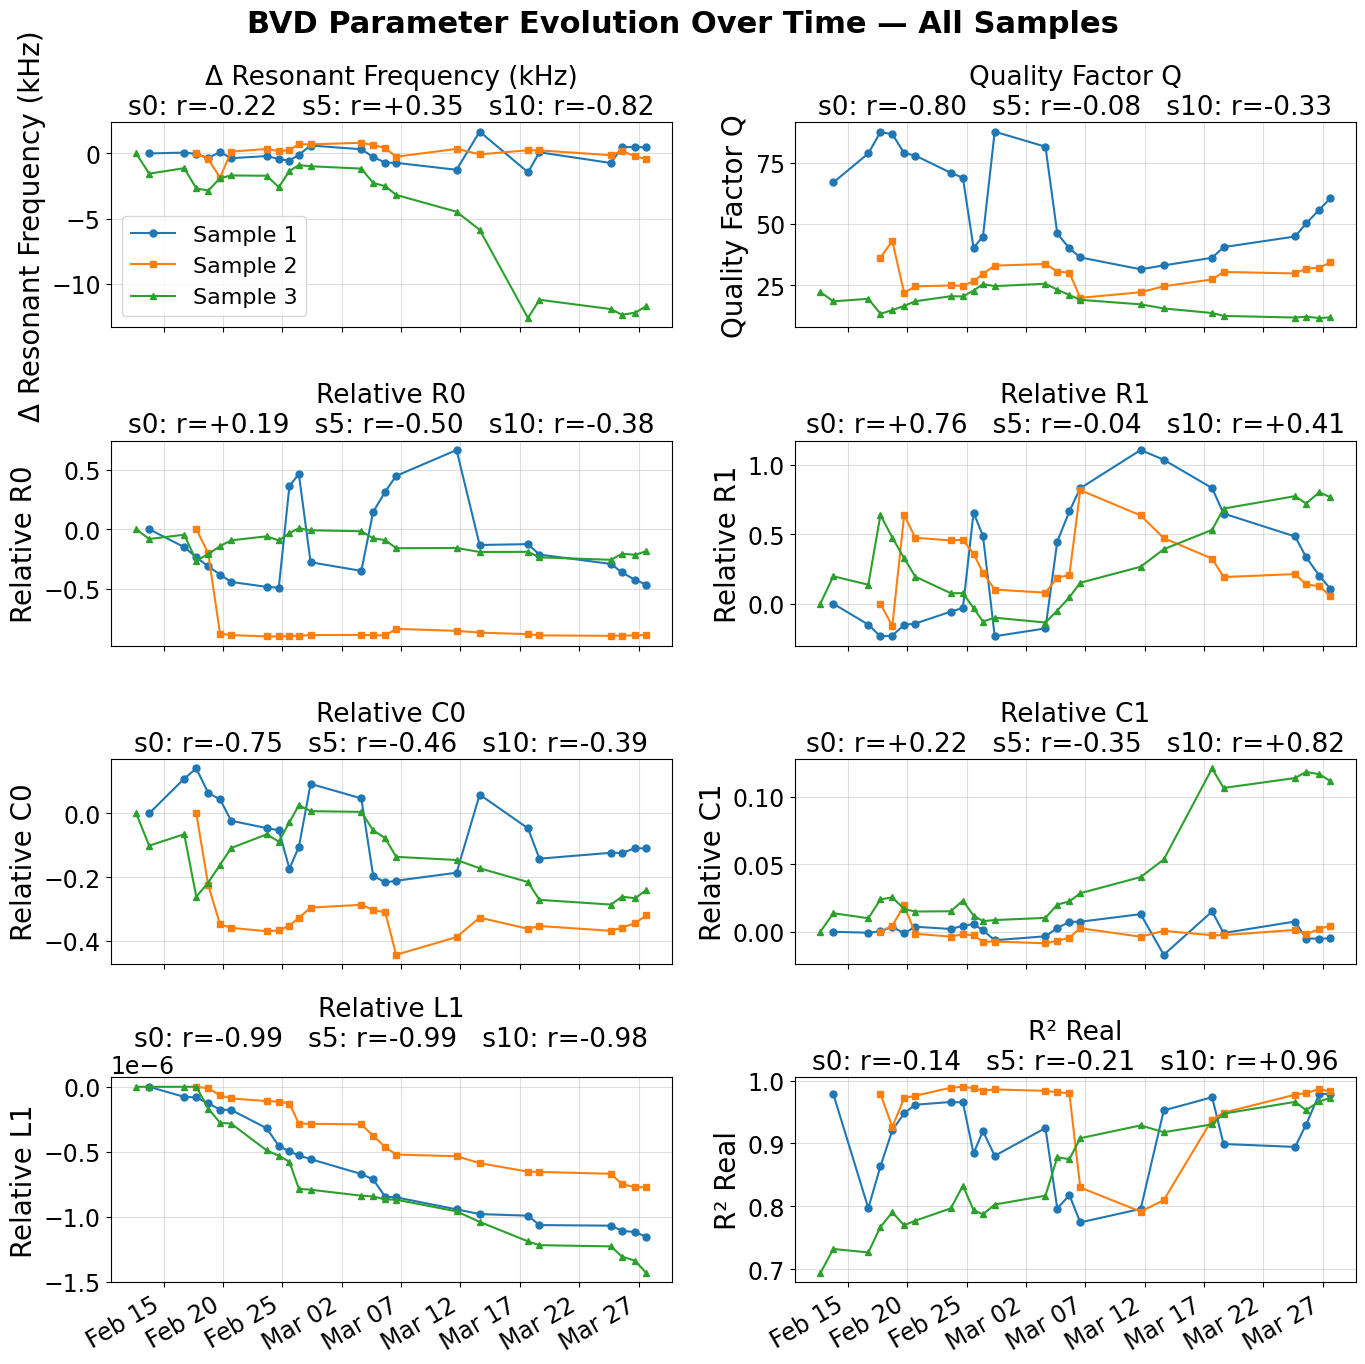

In [8]:
import matplotlib.pyplot as plt

font_scale = 4

plt.rcParams.update({
    'font.size': 14 + font_scale,
    'axes.labelsize': 16 + font_scale,
    'axes.titlesize': 15 + font_scale,
    'xtick.labelsize': 13 + font_scale,
    'ytick.labelsize': 13 + font_scale,
    'legend.fontsize': 12 + font_scale,
    'figure.titlesize': 18 + font_scale,
})

# Compute delta f_res_khz per sample using results_df
results_df = results_df.sort_values(['sample', 'timestamp']).copy()

# baseline = first f_res_khz for each sample
results_df['f_res_khz_baseline'] = (
    results_df.groupby('sample')['f_res_khz'].transform('first')
)

# delta
results_df['delta_f_res_khz'] = (
    results_df['f_res_khz'] - results_df['f_res_khz_baseline']
)

# optional cleanup
results_df = results_df.drop(columns=['f_res_khz_baseline'])
if results_df.empty:
    print("No results to plot.")
else:
    # ── Load mass loss data for correlation ───────────────────────────────────
    mass_loss_path = os.path.join(CORROSION_DATASET_PATH, 'mass_loss.csv')
    ml_df = pd.read_csv(mass_loss_path, parse_dates=['Date'])

    # Add a normalised date column to results_df for merging
    rdf = results_df.copy()
    rdf['_date'] = rdf['timestamp'].dt.normalize()

    # ── Compute relative change for circuit parameters ────────────────────────
    for col in ['R0', 'C0', 'R1', 'L1', 'C1']:
        rdf[f'{col}_0'] = rdf.groupby('sample')[col].transform('first')
        rdf[f'delta_{col}'] = rdf[col] - rdf[f'{col}_0']
        rdf[f'rel_{col}'] = (
            rdf[f'delta_{col}'] / (rdf[f'{col}_0'].abs() + 1e-30)
        )

    params_to_plot = [
        ('delta_f_res_khz', 'Δ Resonant Frequency (kHz)'),
        ('Q_factor',        'Quality Factor Q'),
        ('rel_R0',          'Relative R0'),
        ('rel_R1',          'Relative R1'),
        ('rel_C0',          'Relative C0'),
        ('rel_C1',          'Relative C1'),
        ('rel_L1',          'Relative L1'),
        ('r2_real',         'R² Real'),
    ]

    n_cols = 2
    n_rows = (len(params_to_plot) + 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5), sharex=True)
    axes = axes.flatten()

    for ax_idx, (col, ylabel) in enumerate(params_to_plot):
        ax = axes[ax_idx]
        corr_parts = []

        for sample_name in SAMPLES:
            meta = SAMPLE_META[sample_name]
            sdf  = rdf[rdf['sample'] == sample_name].sort_values('timestamp')
            if sdf.empty:
                continue
            ax.plot(sdf['timestamp'], sdf[col],
                    color=meta['color'], marker=meta['marker'],
                    linewidth=1.5, markersize=5, label=meta['label'])

            # Pearson r between this parameter and cumulative mass loss
            ml_s   = ml_df[ml_df['Sample'] == sample_name][['Date', 'Cumulative_Mass_Loss_g']]
            daily  = sdf[['_date', col]].groupby('_date', as_index=False)[col].mean()
            merged = daily.merge(ml_s, left_on='_date', right_on='Date', how='inner')
            if len(merged) >= 3:
                r    = merged[col].corr(merged['Cumulative_Mass_Loss_g'])
                snum = sample_name.split('_')[1]
                corr_parts.append(f"s{snum}: r={r:+.2f}")

        ax.set_ylabel(ylabel)
        corr_text = '   '.join(corr_parts)
        ax.set_title(f"{ylabel}\n{corr_text}" if corr_parts else ylabel)
        ax.grid(True, alpha=0.4)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        if ax_idx == 0:
            ax.legend()

    for ax in axes[len(params_to_plot):]:
        ax.set_visible(False)

    fig.suptitle("BVD Parameter Evolution Over Time — All Samples", fontweight='bold')
    plt.tight_layout()
    plt.show()


# 8. Individual Fit Quality

Renders one diagnostic figure per (timestamp x sample) so you can visually inspect
the circuit fit against the raw data.

Disabled by default — set PLOT_INDIVIDUAL_FITS = True in the Configuration section
to enable. With all sessions loaded this produces ~50 figures, so it is best used
after narrowing the date window to the sessions of interest.



In [9]:

if not PLOT_INDIVIDUAL_FITS:
    print("Individual fit plots are disabled. Set PLOT_INDIVIDUAL_FITS = True in the Configuration section to enable.")
else:
    for _, row in results_df.iterrows():
        ts    = row['timestamp']
        sname = row['sample']
        subset = data[(data['timestamp'] == ts) & (data['sample'] == sname)]
        if subset.empty:
            continue
        frequency = subset['Frequency (Hz)'].values
        z_complex = subset['Z_real'].values + 1j * subset['Z_imag'].values
        params    = [row['R0'], row['C0'], row['R1'], row['L1'], row['C1']]
        title_str = f"{sname}  |  {ts.strftime('%Y-%m-%d %H:%M')}  |  {row['condition']}"
        bvd.plot_bvd_fit(frequency, z_complex, params, title=title_str)


Individual fit plots are disabled. Set PLOT_INDIVIDUAL_FITS = True in the Configuration section to enable.
